|<h2>Course:</h2>|<h1><a href="https://udemy.com/course/deeplearning_x/?couponCode=202508" target="_blank">A deep understanding of deep learning</a></h1>|
|-|:-:|
|<h2>Section:</h2>|<h1>Metaparameters (activations, optimizers)<h1>|
|<h2>Lecture:</h2>|<h1><b>CodeChallenge: Compare relu variants<b></h1>|

<br>

<h5><b>Teacher:</b> Mike X Cohen, <a href="https://sincxpress.com" target="_blank">sincxpress.com</a></h5>
<h5><b>Course URL:</b> <a href="https://udemy.com/course/deeplearning_x/?couponCode=202508" target="_blank">udemy.com/course/deeplearning_x/?couponCode=202508</a></h5>
<i>Using the code without the course may lead to confusion or errors.</i>

In [1]:
### import libraries

# for DL modeling
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

# for number-crunching
import numpy as np
import scipy.stats as stats

# for dataset management
import pandas as pd

# for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import and process the data

In [2]:
# import the data
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
data = pd.read_csv(url,sep=';')
data = data[data['total sulfur dioxide']<200] # drop a few outliers

# z-score all columns except for quality
cols2zscore = data.keys()
cols2zscore = cols2zscore.drop('quality')
data[cols2zscore] = data[cols2zscore].apply(stats.zscore)
    
display(data.head())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,-0.528350,0.960657,-1.391823,-0.452579,-0.244648,-0.464558,-0.382535,0.556807,1.288470,-0.580216,-0.959307,5
1,-0.298673,1.966614,-1.391823,0.049020,0.222827,0.877032,0.654661,0.025923,-0.723652,0.127837,-0.583341,5
2,-0.298673,1.295976,-1.185980,-0.165951,0.095334,-0.081247,0.246069,0.132100,-0.334209,-0.049176,-0.583341,5
3,1.653579,-1.386577,1.489975,-0.452579,-0.265897,0.110409,0.434650,0.662984,-0.983280,-0.462207,-0.583341,6
4,-0.528350,0.960657,-1.391823,-0.452579,-0.244648,-0.464558,-0.382535,0.556807,1.288470,-0.580216,-0.959307,5


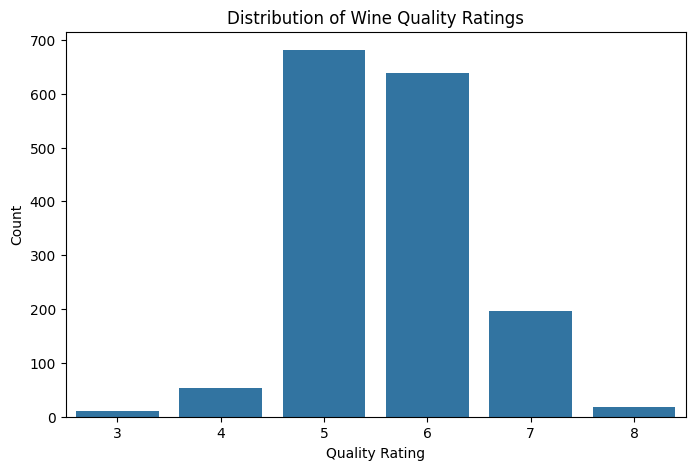

In [3]:
# Plot histogram of quality values
plt.figure(figsize=(8,5))
sns.countplot(x='quality', data=data)
plt.title('Distribution of Wine Quality Ratings')
plt.xlabel('Quality Rating')
plt.ylabel('Count')
plt.show()

# Re-organize the data: train/test in DataLoaders

In [4]:
def create_data_loaders(data, cols2zscore, quality_threshold:float=5.0):
    # convert from pandas dataframe to tensor
    data['boolQuality'] = 0
    data.loc[data['quality'] > quality_threshold, 'boolQuality'] = 1
    num_good = data['boolQuality'].where(data['boolQuality']==1).count()
    num_bad  = data['boolQuality'].where(data['boolQuality']==0).count()

    dataT  = torch.tensor( data[cols2zscore].values ).float()
    labels = torch.tensor( data['boolQuality'].values ).float()
    labels = labels[:,None] # transform to matrix
    
    # use scikitlearn to split the data
    train_data,test_data, train_labels,test_labels = train_test_split(dataT, labels, test_size=.2)

    # then convert them into PyTorch Datasets (note: already converted to tensors)
    train_data = torch.utils.data.TensorDataset(train_data,train_labels)
    test_data  = torch.utils.data.TensorDataset(test_data,test_labels)

    # finally, translate into dataloader objects
    batchsize    = 64
    train_loader = DataLoader(train_data,batch_size=batchsize,shuffle=True,drop_last=True)
    test_loader  = DataLoader(test_data,batch_size=test_data.tensors[0].shape[0])

    return train_loader, test_loader, num_good, num_bad

# Now for the DL part

In [5]:
# create a class for the model

class ANNwine(nn.Module):
  def __init__(self,actfun):
    super().__init__()

    ### input layer
    self.input = nn.Linear(11,16)

    ### hidden layers
    self.fc1 = nn.Linear(16,32)
    self.fc2 = nn.Linear(32,32)

    ### output layer
    self.output = nn.Linear(32,1)

    # activation funcion to pass through
    self.actfun = actfun

  # forward pass
  def forward(self,x):
    # get activation function type
    # this code replaces torch.relu with torch.<self.actfun>
    actfun = getattr(torch.nn,self.actfun)
    x = actfun()( self.input(x) )
    x = actfun()( self.fc1(x) )
    x = actfun()( self.fc2(x) )
    return self.output(x)

# Train the model

In [6]:
# a function that trains the model

def trainTheModel(winenet, train_loader, test_loader, numepochs=500):

  # loss function and optimizer
  lossfun = nn.BCEWithLogitsLoss()
  optimizer = torch.optim.Adam(winenet.parameters(),lr=1e-3, weight_decay=1e-5)

  # initialize losses
  losses   = torch.zeros(numepochs)
  trainAcc = []
  testAcc  = []

  # loop over epochs
  for epochi in range(numepochs):

    # switch on training mode
    winenet.train()

    # loop over training data batches
    batchAcc  = []
    batchLoss = []
    for X,y in train_loader:

      # forward pass and loss
      yHat = winenet(X)
      loss = lossfun(yHat,y)

      # backprop
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      # loss from this batch
      batchLoss.append(loss.item())

      # compute training accuracy for this batch
      batchAcc.append( 100*torch.mean(((yHat>0) == y).float()).item() )
    # end of batch loop...

    # now that we've trained through the batches, get their average training accuracy
    trainAcc.append( np.mean(batchAcc) )

    # and get average losses across the batches
    losses[epochi] = np.mean(batchLoss)

    # test accuracy
    winenet.eval()
    X,y = next(iter(test_loader)) # extract X,y from test dataloader
    with torch.no_grad(): # deactivates autograd
      yHat = winenet(X)
      testAcc.append( 100*torch.mean(((yHat>0) == y).float()).item() )

  # function output
  return trainAcc,testAcc,losses

In [7]:
numepochs = 500
quality_threshold_list = [4.5, 5.5, 6.5]
trainAcc = np.zeros((numepochs, len(quality_threshold_list)))
testAcc  = np.zeros((numepochs, len(quality_threshold_list)))
losses_list = np.zeros((numepochs, len(quality_threshold_list)))
for qti, qt in enumerate(quality_threshold_list):
    train_loader, test_loader, num_good, num_bad = create_data_loaders(data, cols2zscore, quality_threshold=qt)
    winenet = ANNwine('LeakyReLU')
    trainAcc[:,qti], testAcc[:,qti], losses = trainTheModel(winenet, train_loader, test_loader, numepochs)
    losses_list[:,qti] = losses
    print(f'QT = {qt}: num_good = {num_good}\t\tnum_bad = {num_bad}')

QT = 4.5: num_good = 1534		num_bad = 63
QT = 5.5: num_good = 853		num_bad = 744
QT = 6.5: num_good = 215		num_bad = 1382


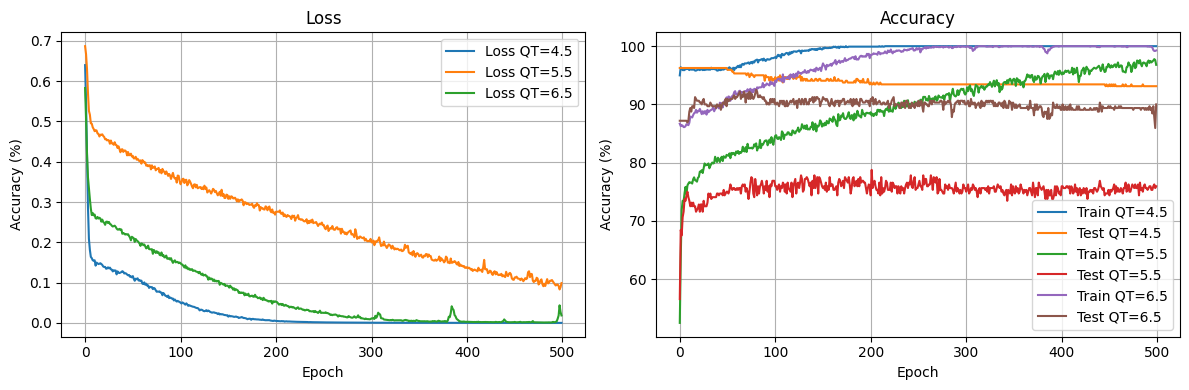

In [8]:
# plot some results
fig,axs = plt.subplots(1,2,figsize=(12,4))

for qti, qt in enumerate(quality_threshold_list):
    axs[0].plot(losses_list[:,qti], label=f'Loss QT={qt}')
axs[0].set_title('Loss')

for qti, qt in enumerate(quality_threshold_list):
    axs[1].plot(trainAcc[:,qti], label=f'Train QT={qt}')
    axs[1].plot(testAcc[:,qti], label=f'Test QT={qt}')
axs[1].set_title('Accuracy')

for a in axs:
  a.legend()
  a.set_xlabel('Epoch')
  a.set_ylabel('Accuracy (%)')
  a.grid()
fig.tight_layout()
plt.show()

# Additional explorations

In [ ]:
# 1) L2 regularization is supposed to help minimize over-training. Try adding an L2 regularizer and see if that
#    helps reduce the bias due to unbalanced N.
# Answer: There is minimal difficult noticeable deifference in towards increased accuracy.
#
# 2) Does the unbalanced design get better (that is, less unbalanced) if the train/test split is 80/20 instead of 90/10?
#    Try it and find out! Note that you don't need to train models for this question; you simply need to modify the data
#    splitting function and then compute the proportions of the two categories.
# Answer: It does not help.
#